# ==============================================================================
# UNIVERSIDADE PRESBITERIANA MACKENZIE
## Faculdade de Computação e Informática - FCI
## Disciplina: Inteligência Artificial (7°N CC - Noite)
### Professor: Dr. Ivan Carlos Alcântara de Oliveira
#
# PROJETO: Aplicação de Machine Learning na Distinção entre Trânsitos Planetários e Falsos Positivos Astronômicos (Catálogo Kepler)

# INTEGRANTES:
## - Davi Martins Figueiredo (RA: 10374878)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [24]:
# 1. CARREGAMENTO E CONFIGURAÇÃO DOS DADOS
print("=> Carregando e estruturando os dados do catálogo Kepler...")

caminho_arquivo = "/content/dataset_exo.xlsx - cumulative_2024 07 31_07 32 29.csv"

df = pd.read_excel(caminho_arquivo, comment='#')

print(f"\n=> Dataset carregado com sucesso! Total de registros limpos: {len(df)}")

=> Carregando e estruturando os dados do catálogo Kepler...

=> Dataset carregado com sucesso! Total de registros limpos: 9564


In [25]:
# Limpando os nomes das colunas (remove espaços em branco invisíveis que o Excel deixa)
df.columns = df.columns.str.strip()

# Exibe as colunas encontradas para checarmos se o alinhamento deu certo
print("\nColunas identificadas no seu arquivo:", list(df.columns[:5]), "... (e mais)")


Colunas identificadas no seu arquivo: ['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition'] ... (e mais)


In [26]:
# Filtrando linhas com valores nulos nas colunas que serão utilizadas
features = ['koi_model_snr', 'koi_period', 'koi_depth']
df = df.dropna(subset=features + ['koi_disposition'])

In [27]:
# Mapeamento do Target: Planetas Confirmados/Candidatos = 1, Falsos Positivos = 0
df['target'] = df['koi_disposition'].apply(lambda x: 0 if x == 'FALSE POSITIVE' else 1)

In [28]:
X = df[features]
y = df['target']

In [29]:
# DIVISÃO DO DATASET (TREINO E TESTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("=> Dados divididos com sucesso (80% Treino / 20% Teste).")

=> Dados divididos com sucesso (80% Treino / 20% Teste).


In [30]:
# TREINAMENTO DO MODELO RANDOM FOREST
print("=> Inicializando e treinando o classificador Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("=> Treinamento concluído.")

=> Inicializando e treinando o classificador Random Forest...
=> Treinamento concluído.


In [31]:
# PREDIÇÃO E AVALIAÇÃO DE PERFORMANCE
print("\n" + "="*50)
print("             MÉTRICAS DE PERFORMANCE DO MODELO")
print("="*50)


y_pred = rf_model.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo: {acuracia * 100:.2f}%\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Falso Positivo', 'Planeta']))

print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


             MÉTRICAS DE PERFORMANCE DO MODELO
Acurácia Geral do Modelo: 76.44%

Relatório de Classificação:
                precision    recall  f1-score   support

Falso Positivo       0.76      0.76      0.76       914
       Planeta       0.76      0.76      0.76       915

      accuracy                           0.76      1829
     macro avg       0.76      0.76      0.76      1829
  weighted avg       0.76      0.76      0.76      1829

Matriz de Confusão:
[[699 215]
 [216 699]]


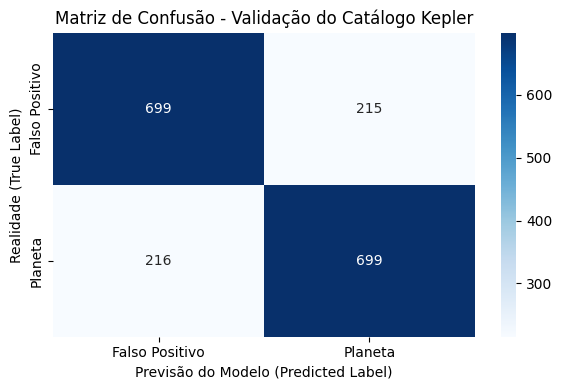

In [32]:
# Gráfico 1: Matriz de Confusão (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Falso Positivo', 'Planeta'], yticklabels=['Falso Positivo', 'Planeta'])
plt.title('Matriz de Confusão - Validação do Catálogo Kepler')
plt.ylabel('Realidade (True Label)')
plt.xlabel('Previsão do Modelo (Predicted Label)')
plt.tight_layout()
plt.savefig('matriz_confusao.png')
plt.show()

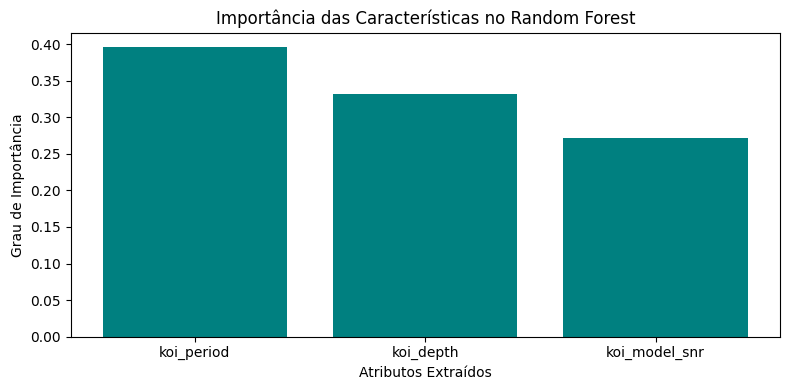

In [33]:
# Gráfico 2: Importância das Características (Feature Importance)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.title('Importância das Características no Random Forest')
plt.bar(range(X.shape[1]), importances[indices], align='center', color='teal')
plt.xticks(range(X.shape[1]), [features[i] for i in indices])
plt.xlabel('Atributos Extraídos')
plt.ylabel('Grau de Importância')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()